In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, accuracy_score
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [2]:
# Read data in CSV file

df = pd.read_csv("wc1.csv")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (24232, 13)


,inline_count,external_count,onclick_count,onload_count,onchange_count,avg_inline_script_block,avg_external_script_block,avg_onclick_count,avg_onload_count,avg_onchange_count,avg_cyc_complexity,library_code_count,type
0,21.0,23.0,1,131.0,0.0,0.0,662.062500,30737,4,16,0.812500,13,alexa
1,13.0,30.0,2,4.0,1.0,0.0,55.777778,2951,12,18,0.555556,10,alexa
2,0.0,3.0,1,0.0,0.0,0.0,207.000000,387,2,1,1.000000,1,phish
3,21.0,11.0,1,10.0,1.0,0.0,104.800000,1505,2,5,0.400000,2,alexa
4,10.0,5.0,1,0.0,0.0,0.0,473.000000,4121,2,3,1.000000,3,alexa


In [3]:
# Seperating values based on ‘type’ column to 0 and 1

df['type'] = df['type'].map({'alexa':0, 'phish':1})
print(df['type'].value_counts())


type
0    17562
1     6670
Name: count, dtype: int64


In [4]:
# Splitting dataset 

X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=133, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (16235, 12)
Test shape: (7997, 12)


In [5]:
# Initializing and training the Logistic Regression model

model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=133)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=133, solver='liblinear')

In [6]:
# Making predictions on test data

y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]


In [7]:

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred),3))


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.88      5796
           1       0.76      0.52      0.62      2201

    accuracy                           0.82      7997
   macro avg       0.80      0.73      0.75      7997
weighted avg       0.82      0.82      0.81      7997

Accuracy: 0.822


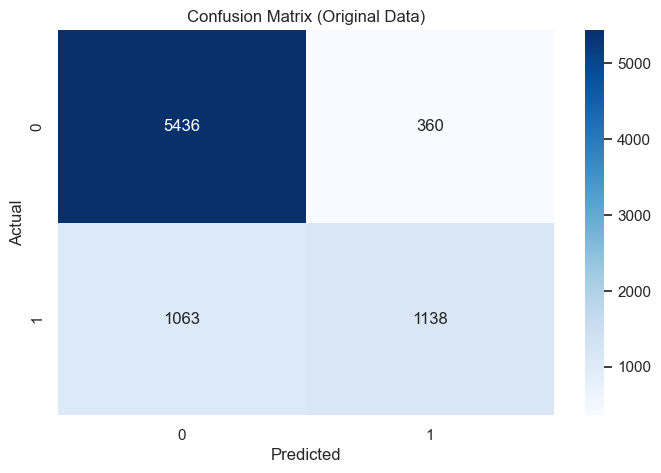

In [8]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Original Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


AUC Score: 0.849


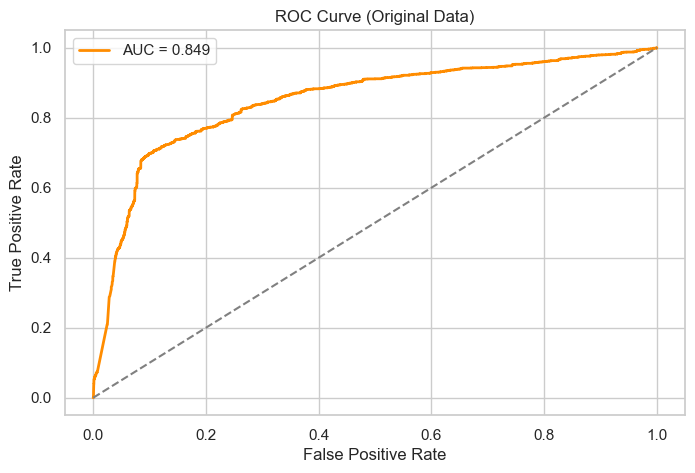

In [9]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
print("AUC Score:", round(roc_auc,3))

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Original Data)")
plt.legend()
plt.show()


Feature importance (original data):


,Feature,Coefficient
2,onclick_count,0.110460
4,onchange_count,0.033212
7,avg_onclick_count,0.000006
6,avg_external_script_block,-0.001108
8,avg_onload_count,-0.002084
3,onload_count,-0.005468
5,avg_inline_script_block,-0.006770
0,inline_count,-0.007824
10,avg_cyc_complexity,-0.025261
1,external_count,-0.030358


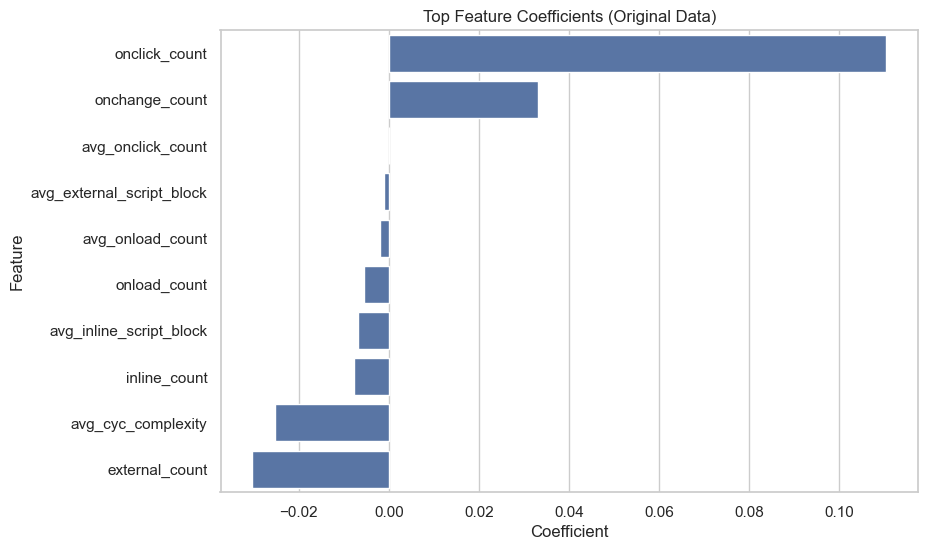

In [10]:
# Feature importance analysis

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Feature importance (original data):")
display(importance.head(10))

plt.figure(figsize=(9,6))
sns.barplot(y='Feature', x='Coefficient', data=importance.head(10))
plt.title("Top Feature Coefficients (Original Data)")
plt.show()


In [11]:
# K-Fold Cross-Validation

kfold = KFold(n_splits=5, shuffle=True, random_state=133)
cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
print("Cross-Validation Accuracies:", np.round(cv_results,3))
print("Mean CV Accuracy:", round(cv_results.mean(),3))


Cross-Validation Accuracies: [0.819 0.827 0.828 0.788 0.835]
Mean CV Accuracy: 0.819


In [12]:
# Splitting train data to train 

X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=133
)


In [13]:
# Selecting the model with the best accuracy

val_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=133)
val_model.fit(X_train2, y_train2)
val_pred = val_model.predict(X_val)
print("Validation Accuracy:", round(accuracy_score(y_val, val_pred),3))


Validation Accuracy: 0.802


In [14]:
# Running the best model for the test data set

test_pred = val_model.predict(X_test)
print("Test Accuracy:", round(accuracy_score(y_test, test_pred),3))


Test Accuracy: 0.796


In [15]:
# Comparing test set predictions with ground truth labels

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': test_pred})
display(comparison.head(10))


,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [16]:
# Normalizing columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (24232, 12)


In [17]:
# Splitting normalized data into train and test sets

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_scaled, y, test_size=0.33, random_state=133, stratify=y
)


In [18]:
# Training logistic regression model on normalized data

model_n = LogisticRegression(max_iter=1000, solver='liblinear', random_state=133)
model_n.fit(X_train_n, y_train_n)


LogisticRegression(max_iter=1000, random_state=133, solver='liblinear')

Accuracy (Normalized Data): 0.823

Confusion Matrix (Normalized Data):
 [[5360  436]
 [ 980 1221]]


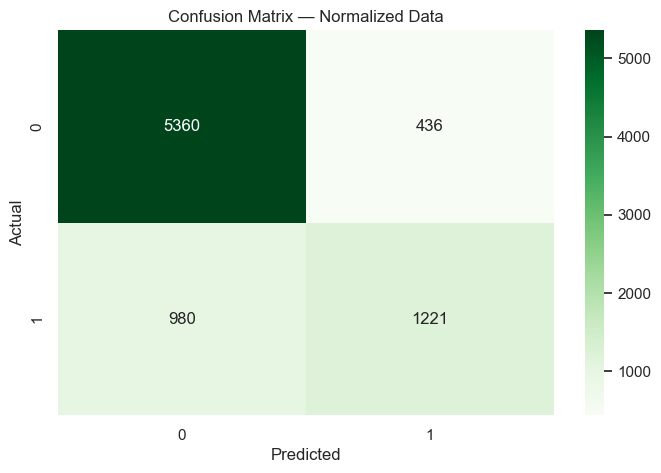


Classification Report (Normalized Data):

              precision    recall  f1-score   support

           0       0.85      0.92      0.88      5796
           1       0.74      0.55      0.63      2201

    accuracy                           0.82      7997
   macro avg       0.79      0.74      0.76      7997
weighted avg       0.82      0.82      0.81      7997

AUC Score (Normalized Data): 0.847


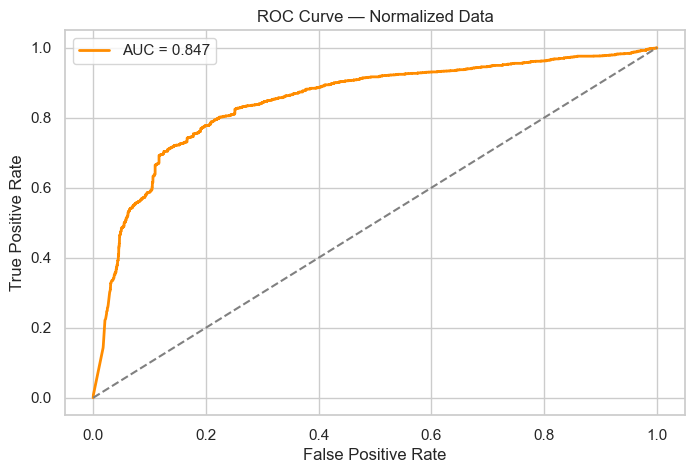

In [19]:
# Logistic Regression on normalized data

y_pred_n = model_n.predict(X_test_n)
y_pred_prob_n = model_n.predict_proba(X_test_n)[:, 1]

# 1️ Accuracy
acc_n = accuracy_score(y_test_n, y_pred_n)
print(f"Accuracy (Normalized Data): {acc_n:.3f}")

# 2️ Confusion Matrix
cm_n = confusion_matrix(y_test_n, y_pred_n)
print("\nConfusion Matrix (Normalized Data):\n", cm_n)

sns.heatmap(cm_n, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix — Normalized Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 3️ Classification Report
print("\nClassification Report (Normalized Data):\n")
print(classification_report(y_test_n, y_pred_n))

# 4️ ROC Curve
fpr_n, tpr_n, _ = roc_curve(y_test_n, y_pred_prob_n)
roc_auc_n = auc(fpr_n, tpr_n)
print(f"AUC Score (Normalized Data): {roc_auc_n:.3f}")

plt.plot(fpr_n, tpr_n, color='darkorange', lw=2, label=f"AUC = {roc_auc_n:.3f}")
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Normalized Data")
plt.legend()
plt.show()


Feature Importance (Normalized Data):


,Feature,Coefficient
11,library_code_count,0.385766
4,onchange_count,0.136586
7,avg_onclick_count,0.056959
8,avg_onload_count,0.044594
5,avg_inline_script_block,-0.129972
0,inline_count,-0.154937
3,onload_count,-0.210436
2,onclick_count,-0.228890
6,avg_external_script_block,-0.436581
10,avg_cyc_complexity,-0.460036


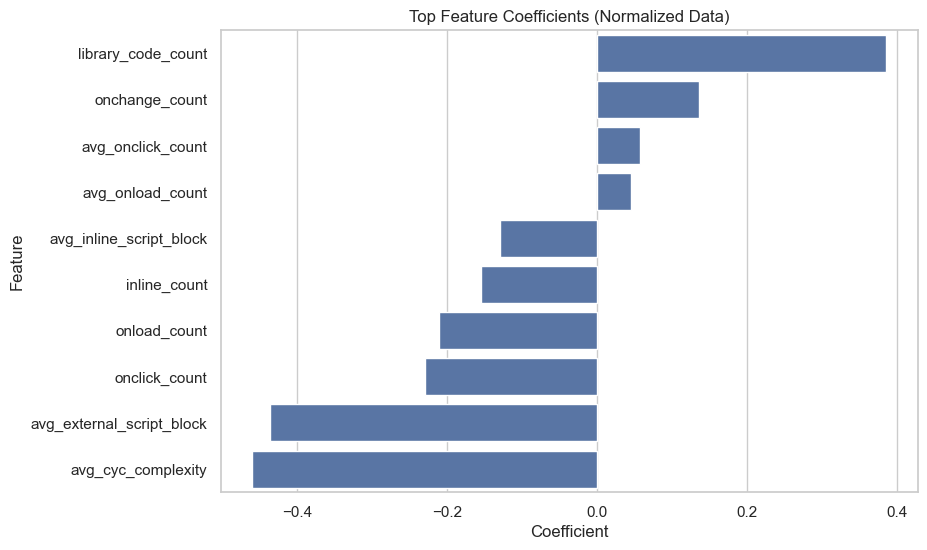

In [20]:
# Feature importance analysis for normalized data

importance_n = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_n.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Feature Importance (Normalized Data):")
display(importance_n.head(10))

plt.figure(figsize=(9,6))
sns.barplot(y='Feature', x='Coefficient', data=importance_n.head(10))
plt.title("Top Feature Coefficients (Normalized Data)")
plt.show()
